<a href="https://colab.research.google.com/github/pd-25/ML-algorithm-implements/blob/main/naive_bayes/spam_sms_naive_byes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np


In [3]:
df = pd.read_csv('spam.csv',encoding='latin-1')


In [4]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
1896,ham,I tot u outside cos darren say u come shopping...,NaN,NaN,NaN
5004,ham,Guess which pub im in? Im as happy as a pig in...,NaN,NaN,NaN
888,ham,You unbelievable faglord,NaN,NaN,NaN
789,ham,Gud mrng dear hav a nice day,NaN,NaN,NaN
1660,ham,No just send to you. Bec you in temple na.,NaN,NaN,NaN


In [5]:
df.shape

(5572, 5)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [7]:
df.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1, inplace=True)


In [8]:
df.sample(5)

,v1,v2
1761,ham,Got ur mail Dileep.thank you so muchand look f...
2262,ham,It should take about &lt;#&gt; min
2027,ham,No got new job at bar in airport on satsgettin...
5068,ham,Hai dear friends... This is my new &amp; prese...
3350,ham,At what time are you coming.


In [9]:
df.rename(columns={"v1": "target", "v2": "text"}, inplace=True)

In [10]:
df.sample(5)

,target,text
5512,ham,"Just making dinner, you ?"
4788,ham,We're on the opposite side from where we dropp...
469,ham,There are many company. Tell me the language.
533,ham,I'll be late...
245,ham,Too late. I said i have the website. I didn't ...


In [11]:
#If there are messy data like 'hum', ' hum ', 'HUm' then use this below
# df['target_col'] = df['target_col'].str.strip().str.lower().map({'yes': True, 'no': False})

# df['target'].value_counts()
#as we check suing value_count, the data is only 2 type and clean so we use pandas labelencoder
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['target'] = encoder.fit_transform(df['target'])

In [12]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [13]:
df.isnull().sum()

,0
target,0
text,0


In [14]:
df.duplicated().sum()

np.int64(403)

In [15]:
df.drop_duplicates(keep="first", inplace=True)

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df['target'].value_counts()

,count
target,
0,4516
1,653


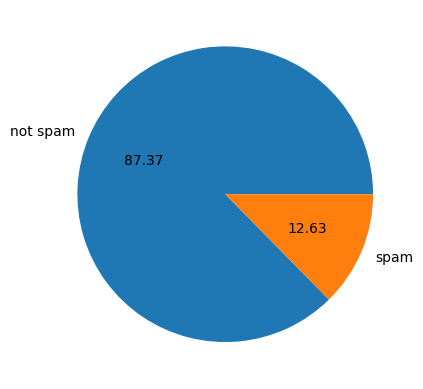

In [18]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(), labels=['not spam', 'spam'], autopct="%0.2f")
plt.show()

In [19]:
#As we get data is imbalanced
#lets create few more column for better performance

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [20]:
df['num_characters'] = df['text'].apply(len)

In [21]:
df.sample(5)

,target,text,num_characters
3896,0,No. Thank you. You've been wonderful,36
2881,0,Hi Harish's rent has been transfred to ur Acnt.,47
2016,0,"Princess, is your kitty shaved or natural?",42
3674,0,Whos this am in class:-),24
3060,0,What u talking bout early morning? It's almost...,66


In [22]:
df['num_words'] = df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [23]:
df.head(5)

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [24]:
df['num_sentences'] = df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [25]:
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [26]:
df[['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


# Now Data Preprocessing
1. Lower case
2. Tokenization (nltk.word_tokenize)
3. Removing Special char
4. Removing stop words and pantuatons (nltk corpus stop words and string pantuations)
5. stemming (nltk stem)

In [31]:
import string
nltk.download('stopwords')
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
from nltk.corpus import stopwords
def transform_text(text: str):
  text = text.lower()
  text = nltk.word_tokenize(text)
  y = []
  for i in text:
    if i.isalnum():
      y.append(i)

  text = y[:]
  y.clear()

  for i in text:
    if i not in stopwords.words('english') and i not in string.punctuation:
      y.append(i)

  text = y[:]
  y.clear()

  for i in text:
    y.append(ps.stem(i))
  return " ".join(y)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [32]:
transform_text('Hello, this is not a &% spamming happening comment?')

'hello spam happen comment'

In [33]:
df['transformed_text'] = df['text'].apply(transform_text)

In [34]:
df.sample(5)

,target,text,num_characters,num_words,num_sentences,transformed_text
4856,0,Thanks and ! Or bomb and date as my phone wan...,58,14,2,thank bomb date phone want say
5258,0,1 in cbe. 2 in chennai.,23,8,2,1 cbe 2 chennai
4701,0,Anytime...,10,2,1,anytim
304,1,SMS. ac Blind Date 4U!: Rodds1 is 21/m from Ab...,146,34,6,sm ac blind date 4u rodds1 aberdeen unit kingd...
398,0,"Good evening Sir, Al Salam Wahleykkum.sharing ...",204,39,1,good even sir al salam happi grace god got off...


Now we basically work with target and transformed_text feature going forward, we still have the other colm, if we need to to do any bacatrack.

# Now will create a word cloud to highlight which word spam is mostly used here

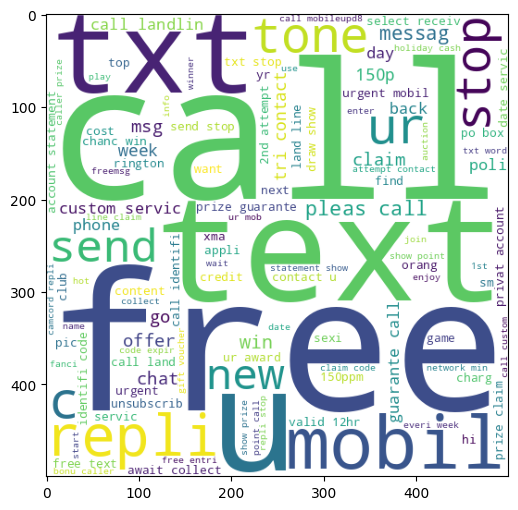

In [35]:
from wordcloud import WordCloud
wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white')

# Now we need on spam colums, use the generate function on spam transformed_text
# df[df['target']==1]['transformed_text']

wc_spam = wc.generate(df[df['target']==1]['transformed_text'].str.cat(sep=" "))
plt.figure(figsize=(15, 6))
plt.imshow(wc_spam)

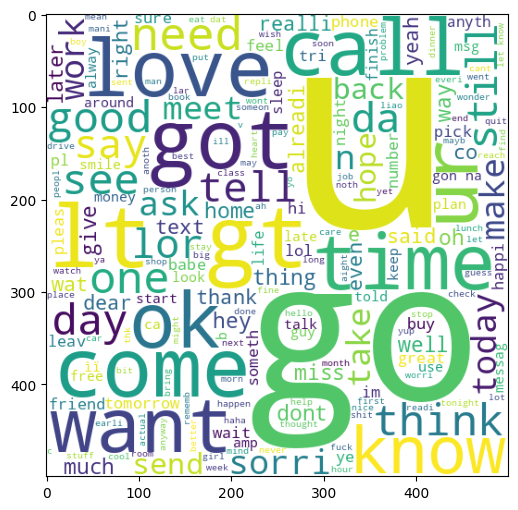

In [36]:
#Now check for ham msg
wc_ham = wc.generate(df[df['target']==0]['transformed_text'].str.cat(sep=" "))
plt.figure(figsize=(15, 6))
plt.imshow(wc_ham)

# Now Model bulding

In [51]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer()

# X = cv.fit_transform(df['transformed_text']).toarray()
X = tfidf.fit_transform(df['transformed_text']).toarray()

In [52]:
X.shape

(5169, 6708)

In [53]:
y = df['target'].values

In [54]:
y

array([0, 0, 1, ..., 0, 0, 0])

In [55]:
from sklearn.model_selection import train_test_split

In [56]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [57]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score

In [58]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [59]:
gnb.fit(X_train, y_train)
y_pred1 = gnb.predict(X_test)
print(f"accuracy_score: {accuracy_score(y_test, y_pred1)}")
print(f"confusion_matrix: {confusion_matrix(y_test, y_pred1)}")
print(f"precision_score: {precision_score(y_test, y_pred1)}")

accuracy_score: 0.8762088974854932
confusion_matrix: [[793 103]
 [ 25 113]]
precision_score: 0.5231481481481481


In [60]:
mnb.fit(X_train, y_train)
y_pred2 = mnb.predict(X_test)
print(f"accuracy_score: {accuracy_score(y_test, y_pred2)}")
print(f"confusion_matrix: {confusion_matrix(y_test, y_pred2)}")
print(f"precision_score: {precision_score(y_test, y_pred2)}")

accuracy_score: 0.9593810444874274
confusion_matrix: [[896   0]
 [ 42  96]]
precision_score: 1.0


In [61]:
bnb.fit(X_train, y_train)
y_pred3 = bnb.predict(X_test)
print(f"accuracy_score: {accuracy_score(y_test, y_pred3)}")
print(f"confusion_matrix: {confusion_matrix(y_test, y_pred3)}")
print(f"precision_score: {precision_score(y_test, y_pred3)}")

accuracy_score: 0.9700193423597679
confusion_matrix: [[893   3]
 [ 28 110]]
precision_score: 0.9734513274336283


In [63]:
# SO we have checked with both bag of words and tfidfs, we found tfidf with multinomial naive bayse is giving good accuricy and precision score also, here the precision_score is preferrable, so we will choose - tfidf with multinomial naive bayse